## Symbols_valid_meta 

### Introduction

This dataset contains metadata about stock market securities listed on different exchanges. Each row represents one stock, ETF, or financial security.

The goal of this analysis is to:

Understand the dataset structure Clean the dataset properly Explore numerical and categorical variables Find meaningful patterns and relationships Generate insights that can help in decision-making

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('symbols_valid_meta.csv')

In [3]:
df.sample(7)

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
6284,Y,SAIL,"SailPoint Technologies Holdings, Inc. Common S...",N,,N,100,N,NaN,SAIL,SAIL,N
349,Y,ANH,Anworth Mortgage Asset Corporation Common Stock,N,,N,100,N,NaN,ANH,ANH,N
7704,Y,VYM,Vanguard High Dividend Yield ETF,P,,Y,100,N,NaN,VYM,VYM,N
3711,Y,IMAX,Imax Corporation Common Stock,N,,N,100,N,NaN,IMAX,IMAX,N
6792,Y,SSY,"SunLink Health Systems, Inc. Common Stock",A,,N,100,N,NaN,SSY,SSY,N
3872,Y,ITUB,Itau Unibanco Banco Holding SA American Deposi...,N,,N,100,N,NaN,ITUB,ITUB,N
317,Y,AMRH,"Ameri Holdings, Inc. - Common Stock",Q,S,N,100,N,N,NaN,AMRH,N


## **Understanding the dataset**

Nasdaq Traded
Y → Yes → Listed/traded on Nasdaq
N → No → Not traded on Nasdaq (could be on New York Stock Exchange or another exchange)

#### Symbol: 

A symbol (or ticker symbol) is a short code that represents a company’s stock in the stock market.(primary key)
#### Security Name: 

A security is any tradable financial instrument listed on exchanges like the Nasdaq Stock Market, such as:

Stocks (e.g., Apple Inc.)
ETFs
Other listed instruments

In [4]:
df['Listing Exchange'].unique()

array(['N', 'P', 'Q', 'A', 'Z'], dtype=object)

### Listing Exchange
N → New York Stock Exchange (NYSE): Large, well-established companies (blue-chip firms)

Q → Nasdaq Stock Market (Nasdaq): Tech-heavy, growth-oriented companies

A → NYSE American: Smaller companies, mid/small-cap focus

P → NYSE Arca:  Mostly ETFs (Exchange-Traded Funds)

Z → BATS Global Markets (now part of Cboe): Alternative electronic exchange

In [5]:
df['Market Category'].unique()

array([' ', 'G', 'Q', 'S'], dtype=object)

#### Market Category
Q (Global Select)  → Elite companies
G (Global Market)  → Mid-level companies
S (Capital Market) → Small / early-stage companies

#### ETF Exchange-Traded Fund
N → ownership in one company
Y → ownership in many assets at once

#### Round Lot Size
It’s the default quantity traders usually buy/sell in one go

#### Test Issue
Y → Yes
👉 This is a test/dummy security (used for system testing, not real trading)
N → No
👉 This is a real, actual stock or ETF

In [6]:
df['Financial Status'].unique()

array([nan, 'N', 'D', 'E', 'H'], dtype=object)

#### Finanacial Status

✅ N → Normal
Company meets all listing requirements on the Nasdaq Stock Market, no financial distress signals

⚠️ D → Deficient
Company is not meeting Nasdaq requirements: Could be due to Low stock price, financial issues, Filing problems



🚫 E → Delinquent
Company has missed required filings (like financial reports)


⛔ H → Deficient & Delinquent
Worst case: Not meeting requirements AND Missing filings



#### CQS Symbol

Symbol → the company’s main ticker (identity)
CQS Symbol → the ticker used in the U.S. quote system (for pricing across exchanges)

Symbol = your name on one platform
CQS Symbol = your name used across major U.S. platforms

#### NASDAQ Symbol
    
NASDAQ Symbol is simply the ticker symbol used specifically on the Nasdaq Stock Market.

#### NextShares
NextShares → basket of companies (but price is fixed later)

#### First look at the dataset

In [7]:
df.shape

(8049, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8049 entries, 0 to 8048
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Nasdaq Traded     8049 non-null   object
 1   Symbol            8049 non-null   object
 2   Security Name     8049 non-null   object
 3   Listing Exchange  8049 non-null   object
 4   Market Category   8049 non-null   object
 5   ETF               8049 non-null   object
 6   Round Lot Size    8049 non-null   int64 
 7   Test Issue        8049 non-null   object
 8   Financial Status  3383 non-null   object
 9   CQS Symbol        4666 non-null   object
 10  NASDAQ Symbol     8049 non-null   object
 11  NextShares        8049 non-null   object
dtypes: int64(1), object(11)
memory usage: 754.7+ KB


In [9]:
df.isnull().sum()

Nasdaq Traded          0
Symbol                 0
Security Name          0
Listing Exchange       0
Market Category        0
ETF                    0
Round Lot Size         0
Test Issue             0
Financial Status    4666
CQS Symbol          3383
NASDAQ Symbol          0
NextShares             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

### Filling Missing values

#### Financial Status

In [11]:
df['Financial Status'].unique()

array([nan, 'N', 'D', 'E', 'H'], dtype=object)

<Axes: xlabel='Financial Status', ylabel='count'>

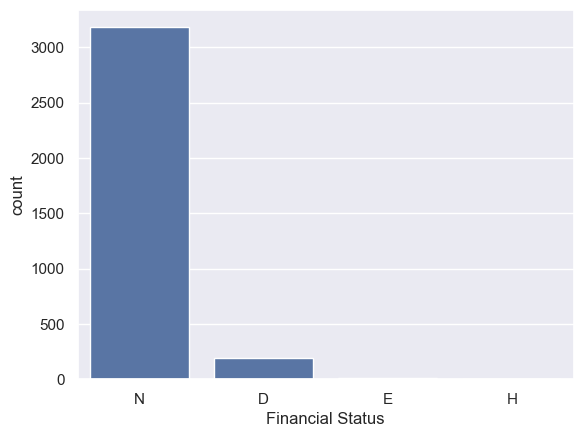

In [12]:
sns.set_style()
sns.set_theme(style='darkgrid')
sns.countplot(x='Financial Status',data=df)

In [13]:
df['Financial Status'].value_counts(normalize=True)*100

Financial Status
N    93.999409
D     5.645876
E     0.236477
H     0.118238
Name: proportion, dtype: float64

The dataset is dominated by financially stable firms, which may introduce class imbalance in any risk-based modeling task.
Distressed categories (D, E, H) collectively form ~6% of the data, making them rare but high-impact cases.
These minority classes likely carry strong predictive signal for risk, volatility, or abnormal behavior.

##### Since more than 50% entries here are Nan, replacing them with N, as filling them with unknown or unspecified would create a new but more dominating category which would be not ideal.

In [14]:
df['Financial Status']=df['Financial Status'].fillna('N')

In [15]:
df.isnull().sum()

Nasdaq Traded          0
Symbol                 0
Security Name          0
Listing Exchange       0
Market Category        0
ETF                    0
Round Lot Size         0
Test Issue             0
Financial Status       0
CQS Symbol          3383
NASDAQ Symbol          0
NextShares             0
dtype: int64

<Axes: xlabel='Financial Status', ylabel='count'>

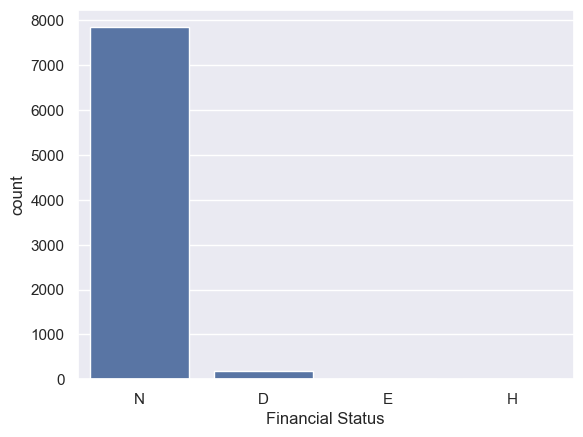

In [16]:
sns.countplot(x='Financial Status',data=df)

In [17]:
df['Financial Status'].value_counts(normalize=True)*100

Financial Status
N    97.477948
D     2.372966
E     0.099391
H     0.049696
Name: proportion, dtype: float64

After filling the missing values in the Financial Status column with **‘N’ (Normal)**, the data becomes even more skewed toward financially stable companies (about 97.5%), with only a small portion falling into Deficient, Delinquent, or both categories. This isn’t just a technical choice—it’s based on how the Nasdaq Stock Market actually works. Companies with financial or compliance issues are explicitly marked with flags like D, E, or H. So when there’s no flag (NaN), it usually means there’s **no known issue**, not that the status is unknown. If we had labeled those missing values as “Unknown,” we would’ve ended up creating a large, meaningless category that doesn’t reflect real-world conditions and could confuse the model. By replacing NaN with ‘N’, we keep the data aligned with how financial statuses are reported in reality, making the feature more reliable and useful for analysis and modeling. 

The distribution is heavily skewed toward financially stable companies (about 97.5% classified as “Normal”), indicating that most firms listed on the Nasdaq Stock Market **meet regulatory and compliance requirements** at a given point in time. Distressed firms—those marked as Deficient, Delinquent, or both—form a very small proportion of the dataset, but they are explicitly flagged, making them easy to identify. From a risk analysis perspective, this small minority is particularly important: despite their low frequency, these firms represent **high-risk entities** that may exhibit greater volatility (moves up and down more sharply and more often), financial instability, or potential delisting risk. As a result, the Financial Status feature becomes highly valuable for isolating and studying risk, even in an otherwise stable dataset, and can be leveraged to build targeted risk indicators or classification models focusing on rare but impactful cases.



#### CQS Symbol

In [18]:
df.sample(10)

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
140,Y,AFLG,First Trust Active Factor Large Cap ETF,P,,Y,100,N,N,AFLG,AFLG,N
3940,Y,JBHT,"J.B. Hunt Transport Services, Inc. - Common Stock",Q,Q,N,100,N,N,NaN,JBHT,N
2143,Y,ELSE,"Electro-Sensors, Inc. - Common Stock",Q,S,N,100,N,N,NaN,ELSE,N
7737,Y,WCN,"Waste Connections, Inc. Common Shares",N,,N,100,N,N,WCN,WCN,N
7695,Y,VVV,Valvoline Inc. Common Stock,N,,N,100,N,N,VVV,VVV,N
801,Y,BKTI,BK Technologies Corporation Common Stock,A,,N,100,N,N,BKTI,BKTI,N
5871,Y,PYZ,Invesco DWA Basic Materials Momentum ETF,Q,G,Y,100,N,N,NaN,PYZ,N
732,Y,BGH,Barings Global Short Duration High Yield Fund ...,N,,N,100,N,N,BGH,BGH,N
3747,Y,INFR,Legg Mason Global Infrastructure ETF,Q,G,Y,100,N,N,NaN,INFR,N
7161,Y,TRHC,"Tabula Rasa HealthCare, Inc. - Common Stock",Q,G,N,100,N,N,NaN,TRHC,N


In [19]:
df_diff = df[
    (df['CQS Symbol'].notna()) & 
    (df['Symbol'].notna()) & 
    (df['CQS Symbol'] != df['Symbol'])
]

In [20]:
df_diff

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
162,Y,AGM$A,Federal Agricultural Mortgage Corporation 5.87...,N,,N,100,N,N,AGMpA,AGM-A,N
1068,Y,CARR.V,Carrier Global Corporation Common Stock When I...,N,,N,100,N,N,CARRw,CARR#,N
7457,Y,UTX.V,United Technologies Corporation Common Stock E...,N,,N,100,N,N,UTXw,UTX#,N


In [21]:
df['CQS Symbol'] = df['CQS Symbol'].fillna(df['Symbol'])

In [22]:
df.isnull().sum()

Nasdaq Traded       0
Symbol              0
Security Name       0
Listing Exchange    0
Market Category     0
ETF                 0
Round Lot Size      0
Test Issue          0
Financial Status    0
CQS Symbol          0
NASDAQ Symbol       0
NextShares          0
dtype: int64

In [23]:
df.sample(10)

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
1401,Y,CNQ,Canadian Natural Resources Limited Common Stock,N,,N,100,N,N,CNQ,CNQ,N
5796,Y,PST,ProShares UltraShort Lehman 7-10 Year Treasury,P,,Y,100,N,N,PST,PST,N
5323,Y,OPY,"Oppenheimer Holdings, Inc. Class A Common Stoc...",N,,N,100,N,N,OPY,OPY,N
5010,Y,NIM,Nuveen Select Maturities Municipal Fund Common...,N,,N,100,N,N,NIM,NIM,N
4566,Y,MEET,"The Meet Group, Inc. - Common Stock",Q,S,N,100,N,N,MEET,MEET,N
3621,Y,IEF,iShares 7-10 Year Treasury Bond ETF,Q,G,Y,100,N,N,IEF,IEF,N
7722,Y,WBIE,WBI BullBear Rising Income 3000 ETF,P,,Y,100,N,N,WBIE,WBIE,N
4304,Y,LEN,Lennar Corporation Class A Common Stock,N,,N,100,N,N,LEN,LEN,N
965,Y,BSMX,"Banco Santander Mexico, S.A., Institucion de B...",N,,N,100,N,N,BSMX,BSMX,N
3277,Y,HCXY,"Hercules Capital, Inc. 6.25% Notes due 2033",N,,N,100,N,N,HCXY,HCXY,N


To handle missing values in the **CQS Symbol** column, we filled them using the corresponding values from the **Symbol** column. This works because both columns essentially represent the same ticker identifier, and in most cases they already match. So when CQS Symbol is missing, the Symbol column acts as a reliable fallback rather than introducing a new or artificial value. This approach keeps the data consistent and avoids unnecessary noise. After this step, the two columns become nearly identical, confirming that CQS Symbol doesn’t add any new information.


In [24]:
df.columns

Index(['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange',
       'Market Category', 'ETF', 'Round Lot Size', 'Test Issue',
       'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares'],
      dtype='object')

### Searching for Suspicious/False Entries

#### Nasdaq Traded

In [25]:
df['Nasdaq Traded'].unique()

array(['Y'], dtype=object)

When we checked the “Nasdaq Traded” column, we found that it contains only a single value, ‘Y’, for all rows in the dataset. This means that every security in the dataset is traded on the Nasdaq Stock Market. However, this does not imply that all companies are listed on Nasdaq, as securities can still be primarily listed on other exchanges but traded through Nasdaq’s systems. Since the column shows no variation across entries, it does not provide any useful information for analysis.

#### Symbol

In [26]:
df['Symbol'].nunique()

8049

All unique companies found

#### Security Name

In [27]:
df['Security Name'].nunique()

8045

In [28]:
df.groupby('Security Name')['Symbol'].nunique().sort_values(ascending=False).head()

Security Name
Urstadt Biddle Properties Inc. Common Stock    2
MFS Municipal Income Trust Common Stock        2
iShares Edge MSCI Intl Size Factor ETF         2
iShares Morningstar Mid-Cap ETF                2
Precision Drilling Corporation Common Stock    1
Name: Symbol, dtype: int64

In [29]:
df[df['Security Name'].duplicated(keep=False)].sort_values('Security Name')

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
1378,Y,CMU,MFS Municipal Income Trust Common Stock,N,,N,100,N,N,CMU,CMU,N
4591,Y,MFM,MFS Municipal Income Trust Common Stock,N,,N,100,N,N,MFM,MFM,N
7289,Y,UBA,Urstadt Biddle Properties Inc. Common Stock,N,,N,100,N,N,UBA,UBA,N
7296,Y,UBP,Urstadt Biddle Properties Inc. Common Stock,N,,N,100,N,N,UBP,UBP,N
3837,Y,ISCF,iShares Edge MSCI Intl Size Factor ETF,P,,Y,100,N,N,ISCF,ISCF,N
3854,Y,ISZE,iShares Edge MSCI Intl Size Factor ETF,P,,Y,100,N,N,ISZE,ISZE,N
4013,Y,JKG,iShares Morningstar Mid-Cap ETF,P,,Y,100,N,N,JKG,JKG,N
4016,Y,JKI,iShares Morningstar Mid-Cap ETF,Q,G,Y,100,N,N,JKI,JKI,N


We are allowing a few duplicates in the **Security Name** column because they are not actual errors—they reflect how the market works. In some cases, the same company or fund can have **more than one trading symbol**, due to reasons like different share classes, multiple listings, or ETF structures. So even though the name is the same, each row represents a slightly different tradable version of that security. Removing these blindly could lead to loss of useful information. Since these duplicates are relatively few and meaningful, we keep them in the dataset while being careful during analysis to avoid double counting.


#### Listing Exchange

In [30]:
df['Listing Exchange'].unique()

array(['N', 'P', 'Q', 'A', 'Z'], dtype=object)

Listing Exchange

N → New York Stock Exchange (NYSE): Large, well-established companies (blue-chip firms)

Q → Nasdaq Stock Market (Nasdaq): Tech-heavy, growth-oriented companies

A → NYSE American: Smaller companies, mid/small-cap focus

P → NYSE Arca: Mostly ETFs (Exchange-Traded Funds)

Z → BATS Global Markets (now part of Cboe): Alternative electronic exchange

In [31]:
df.columns

Index(['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange',
       'Market Category', 'ETF', 'Round Lot Size', 'Test Issue',
       'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares'],
      dtype='object')

#### Market Category

In [32]:
df['Market Category'].unique()

array([' ', 'G', 'Q', 'S'], dtype=object)

<Axes: xlabel='Market Category', ylabel='count'>

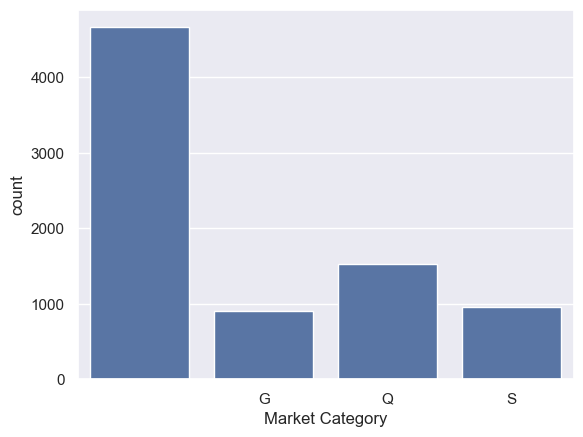

In [33]:
sns.countplot(x='Market Category',data=df)

In [34]:
df['Market Category'].value_counts(normalize=True)*100

Market Category
     57.969934
Q    19.020996
S    11.827556
G    11.181513
Name: proportion, dtype: float64

In [35]:
df.loc[df['ETF'] == 'Y', 'Market Category'] = 'ETF'

In [36]:
df['Market Category'].unique()

array([' ', 'ETF', 'G', 'Q', 'S'], dtype=object)

In [37]:
df['Market Category'].value_counts(normalize=True)*100

Market Category
       35.979625
ETF    26.897751
Q      19.020996
S      11.827556
G       6.274071
Name: proportion, dtype: float64

In [38]:
df[df['Market Category'] == ' ']

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100,N,N,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100,N,N,AA,AA,N
6,Y,AAMC,Altisource Asset Management Corp Com,A,,N,100,N,N,AAMC,AAMC,N
8,Y,AAN,"Aaron's, Inc. Common Stock",N,,N,100,N,N,AAN,AAN,N
11,Y,AAP,Advance Auto Parts Inc Advance Auto Parts Inc W/I,N,,N,100,N,N,AAP,AAP,N
...,...,...,...,...,...,...,...,...,...,...,...,...
8040,Y,ZTO,ZTO Express (Cayman) Inc. American Depositary ...,N,,N,100,N,N,ZTO,ZTO,N
8041,Y,ZTR,Virtus Total Return Fund Inc.,N,,N,100,N,N,ZTR,ZTR,N
8042,Y,ZTS,Zoetis Inc. Class A Common Stock,N,,N,100,N,N,ZTS,ZTS,N
8044,Y,ZUO,"Zuora, Inc. Class A Common Stock",N,,N,100,N,N,ZUO,ZUO,N


In [39]:
df['Market Category'] = df['Market Category'].replace(' ', 'Not Applicable')

In [40]:
df['Market Category'].value_counts(normalize=True)*100

Market Category
Not Applicable    35.979625
ETF               26.897751
Q                 19.020996
S                 11.827556
G                  6.274071
Name: proportion, dtype: float64

To handle the blank (`' '`) values in the **Market Category** column, we didn’t treat them as missing information. Instead, we carefully looked at what those blanks actually represent. The categories **Q, G, and S** are only meant for regular companies listed on the Nasdaq Stock Market. However, many entries in the dataset are **ETFs**, which are not companies but collections of investments, so they don’t fit into these categories. That’s why we labeled those cases as **“ETF”** wherever applicable. For the remaining blanks, we used **“Not Applicable”** to indicate that these securities simply do not belong to the Q/G/S classification system at all, rather than assuming missing or unknown data. This approach keeps the data realistic and avoids forcing incorrect labels, making the feature easier to understand and more reliable for analysis.


#### Round Lot Size

In [41]:
df['Round Lot Size'].unique()

array([100,  10,   1])

In [42]:
df['Round Lot Size'].value_counts(normalize=True)*100

Round Lot Size
100    99.937880
10      0.049696
1       0.012424
Name: proportion, dtype: float64

Although most securities have a **Round Lot Size of 100**, the small number of entries with values **1 and 10 are not errors**. These represent valid but less common trading setups in real markets like the Nasdaq Stock Market. For example, some low-priced stocks or special financial products may allow trading in smaller units to make them more accessible to investors. Similarly, certain ETFs or niche instruments are designed with flexible trading sizes, which can result in lot sizes of 1 or 10. In real life, this is similar to how most products are sold in standard packs (like a pack of 12), but sometimes you can also buy them individually or in smaller bundles. Since these cases reflect genuine market behavior rather than data mistakes, we treat them as valid entries, even though they are rare.

You can buy just 1 share of:

Reliance Industries, Tata Consultancy Services, Infosys and MRF Limited (very expensive stock!) etc.


In [43]:
df.columns

Index(['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange',
       'Market Category', 'ETF', 'Round Lot Size', 'Test Issue',
       'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares'],
      dtype='object')

#### Test Issue

In [44]:
df['Test Issue'].unique()

array(['N'], dtype=object)

In [45]:
df['Test Issue'].nunique()

1

our dataset contains only real, tradable securities

#### Financial Status

In [46]:
df['Financial Status'].unique()

array(['N', 'D', 'E', 'H'], dtype=object)

#### NASDAQ Symbol

In [47]:
df['NASDAQ Symbol'].unique()

array(['A', 'AA', 'AAAU', ..., 'ZYME', 'ZYNE', 'ZYXI'],
      shape=(8049,), dtype=object)

In [48]:
df['NASDAQ Symbol'].nunique()

8049

all unique entries in this column

#### NextShares

In [49]:
df['NextShares'].unique()

array(['N', 'Y'], dtype=object)

all Entries are clean

## **Univariate Analysis**

### Nasdaq Traded


In [50]:
df['Nasdaq Traded'].nunique()

1

### Symbol

In [51]:
df['Symbol'].nunique()

8049

### Security Name

In [52]:
df['Security Name'].nunique()

8045

The columns Nasdaq Traded, Symbol, and Security Name show very limited analytical usefulness due to their distribution patterns. The Nasdaq Traded column contains only a single repeated value throughout the dataset, indicating that all securities are traded on the Nasdaq Stock Market. Since the column has no variation, it does not contribute meaningful insights for further analysis.

On the other hand, the Symbol column is almost entirely unique, as each security is assigned its own ticker symbol for identification purposes. Similarly, most entries in the Security Name column are also unique, representing distinct companies, ETFs, or financial instruments. While a few security names may appear multiple times due to different share classes or related financial products, the column primarily acts as an identifier rather than a feature with analytical patterns.

Overall, these columns are useful for identification and reference, but they provide limited value for discovering broader trends or relationships within the dataset.

In [53]:
df.columns

Index(['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange',
       'Market Category', 'ETF', 'Round Lot Size', 'Test Issue',
       'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares'],
      dtype='object')

### **Listing Exchange**

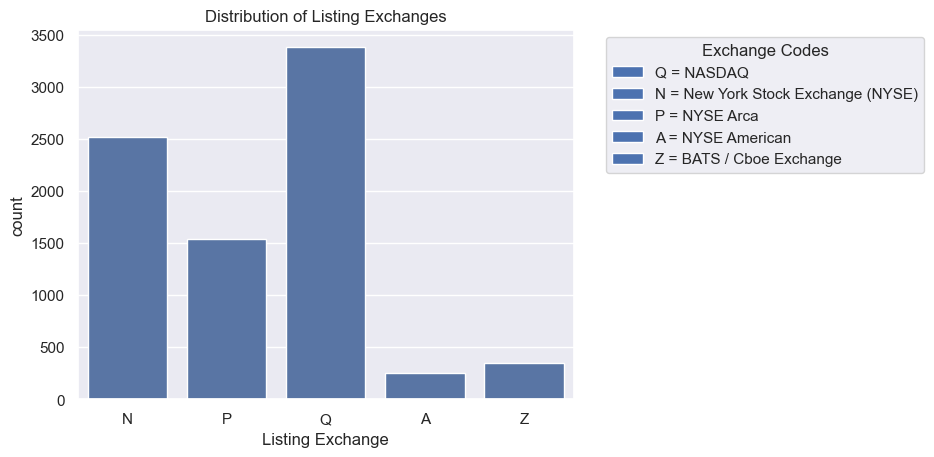

In [54]:
import matplotlib.patches as mpatches

sns.countplot(x='Listing Exchange',data=df)
# Creating custom legend
legend_labels = {
    'Q': 'NASDAQ',
    'N': 'New York Stock Exchange (NYSE)',
    'P': 'NYSE Arca',
    'A': 'NYSE American',
    'Z': 'BATS / Cboe Exchange'
}

patches = [
    mpatches.Patch(label=f"{key} = {value}")
    for key, value in legend_labels.items()
]

plt.legend(handles=patches, title='Exchange Codes', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Distribution of Listing Exchanges')
plt.show()

In [55]:
df['Listing Exchange'].value_counts(normalize=True)*100

Listing Exchange
Q    42.030066
N    31.308237
P    19.157659
Z     4.360790
A     3.143248
Name: proportion, dtype: float64

The **Listing Exchange** distribution shows that the dataset is heavily concentrated around major U.S. stock exchanges, especially the Nasdaq Stock Market and the New York Stock Exchange. The largest share of securities (~42%) belongs to the **Q category**, indicating that Nasdaq-listed companies dominate the dataset. This suggests a strong presence of large, actively traded, and technology-focused firms, as Nasdaq is widely known for hosting many growth-oriented companies. Around **31.3%** of securities are listed under the **N category (NYSE)**, showing that traditional and well-established companies also form a significant portion of the market.

The **P category (~19.2%)** represents NYSE Arca listings, which are commonly associated with ETFs and exchange-traded products. This aligns with earlier observations that the dataset contains a substantial number of ETFs, highlighting that modern financial markets are not limited to company stocks alone. Smaller portions of the data belong to the **Z and A categories**, representing other U.S. exchanges, which indicates some level of diversity in listing sources, although their contribution is relatively minor.

Overall, the dataset reflects a market ecosystem dominated by large and mainstream exchanges, with a strong mix of traditional company stocks and investment products like ETFs. This also suggests that the securities included are generally highly visible, actively traded, and part of the broader U.S. financial market infrastructure.


### **Market Category**

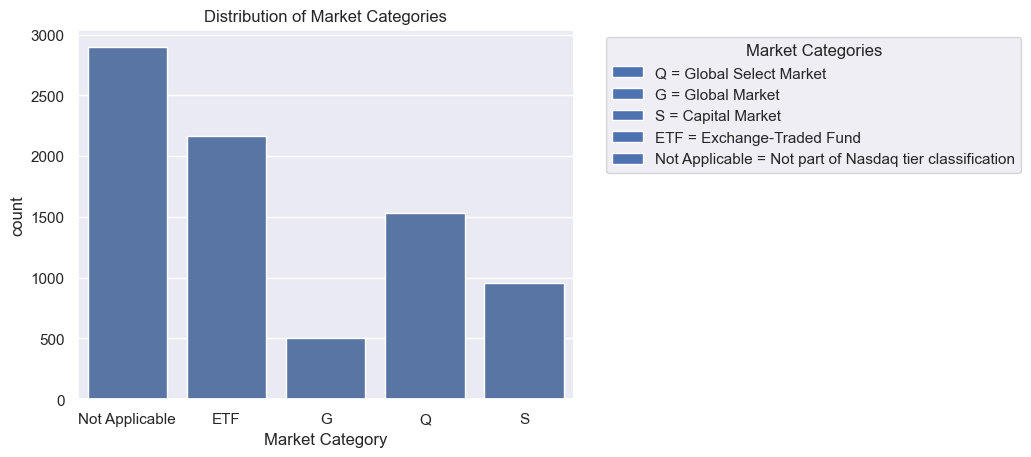

In [56]:
sns.countplot(x='Market Category', data=df)

# Custom legend labels
legend_labels = {
    'Q': 'Global Select Market',
    'G': 'Global Market',
    'S': 'Capital Market',
    'ETF': 'Exchange-Traded Fund',
    'Not Applicable': 'Not part of Nasdaq tier classification'
}

# Create legend patches
patches = [
    mpatches.Patch(label=f"{key} = {value}")
    for key, value in legend_labels.items()
]

plt.legend(handles=patches,
           title='Market Categories',
           bbox_to_anchor=(1.05, 1),
           loc='upper left')

plt.title('Distribution of Market Categories')
plt.show()

In [57]:
df['Market Category'].value_counts(normalize=True)*100

Market Category
Not Applicable    35.979625
ETF               26.897751
Q                 19.020996
S                 11.827556
G                  6.274071
Name: proportion, dtype: float64

The **Market Category** distribution reveals that the dataset contains a diverse mix of securities rather than only traditional company stocks. The largest portion of entries (**~36%**) falls under **“Not Applicable”**, indicating securities that do not belong to Nasdaq’s standard company-tier classification system. These are likely special listings or non-traditional financial instruments. Another major segment (**~26.9%**) consists of **ETFs (Exchange-Traded Funds)**, showing that investment funds form a substantial part of the market ecosystem and highlighting the growing importance of passive investing products in modern financial markets.

Among the categorized company listings, around **19% belong to the Global Select Market (Q)**, which generally includes larger, well-established companies with stricter listing requirements. About **11.8%** fall under the **Capital Market (S)** category, representing smaller and relatively higher-risk firms, while only **~6.3%** belong to the **Global Market (G)** segment, which typically includes mid-sized companies.

Overall, the distribution suggests that the dataset is not dominated solely by traditional corporate stocks, but instead reflects a broader financial market environment that includes ETFs, specialized securities, and companies of varying sizes and market strength.


### ETF

<Axes: xlabel='ETF', ylabel='count'>

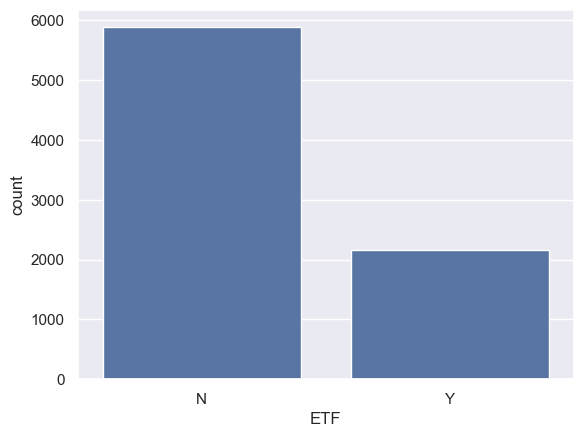

In [58]:
sns.countplot(x='ETF',data=df)

In [59]:
df['ETF'].value_counts(normalize=True)*100

ETF
N    73.102249
Y    26.897751
Name: proportion, dtype: float64

The **ETF** distribution shows that the majority of securities in the dataset (**~73.1%**) are traditional non-ETF securities, while a significant portion (**~26.9%**) consists of **Exchange-Traded Funds (ETFs)**. This indicates that the dataset is not limited to regular company stocks and also includes a considerable number of investment products traded on exchanges like the Nasdaq Stock Market.

The relatively high presence of ETFs reflects how modern financial markets have evolved beyond individual company investing, with many investors now preferring diversified investment vehicles that track indexes, sectors, or themes. At the same time, the dominance of non-ETF securities shows that traditional corporate listings still form the core of the market. Overall, this distribution highlights the diversity of instruments available in the U.S. financial ecosystem and emphasizes the growing role of ETFs in contemporary trading and investment activity.


In [60]:
df.columns


Index(['Nasdaq Traded', 'Symbol', 'Security Name', 'Listing Exchange',
       'Market Category', 'ETF', 'Round Lot Size', 'Test Issue',
       'Financial Status', 'CQS Symbol', 'NASDAQ Symbol', 'NextShares'],
      dtype='object')

### **Round Lot Size**

<Axes: xlabel='Round Lot Size', ylabel='count'>

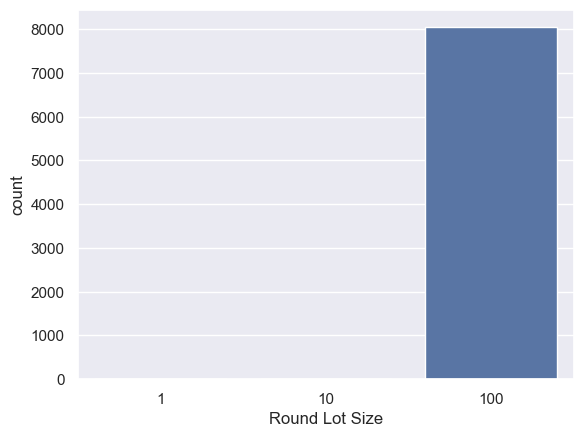

In [61]:
sns.countplot(x='Round Lot Size',data=df)

In [62]:
df['Round Lot Size'].value_counts(normalize=True)*100

Round Lot Size
100    99.937880
10      0.049696
1       0.012424
Name: proportion, dtype: float64

The **Round Lot Size** distribution shows that almost all securities in the dataset (**~99.94%**) use the standard trading unit of **100 shares**, which is the most common lot size in markets like the Nasdaq Stock Market. This indicates a highly standardized trading structure across the majority of securities.

Only a very small fraction of entries have lot sizes of **10 or 1**, representing rare but valid exceptions rather than data errors. These cases may correspond to certain ETFs, low-priced securities, or special financial instruments that allow more flexible trading sizes. In real-world markets, this is similar to how most products are sold in standard packs, while a few can also be purchased individually or in smaller quantities.

Overall, the column shows extremely low variation, suggesting that trading conventions in the market are highly uniform. From an analytical perspective, the feature provides limited differentiation between securities, but it still offers insight into how standardized modern exchange trading systems are.


### Test Issue

In [63]:
df['Test Issue'].unique()

array(['N'], dtype=object)

### **Financial Status**

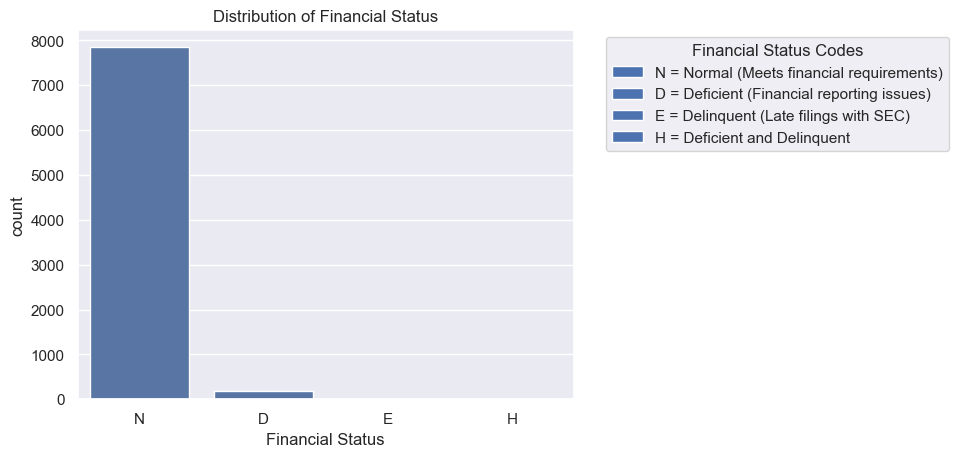

In [64]:
sns.countplot(x='Financial Status', data=df)

# Custom legend labels
legend_labels = {
    'N': 'Normal (Meets financial requirements)',
    'D': 'Deficient (Financial reporting issues)',
    'E': 'Delinquent (Late filings with SEC)',
    'H': 'Deficient and Delinquent'
}

# Create legend patches
patches = [
    mpatches.Patch(label=f"{key} = {value}")
    for key, value in legend_labels.items()
]

plt.legend(handles=patches,
           title='Financial Status Codes',
           bbox_to_anchor=(1.05, 1),
           loc='upper left')

plt.title('Distribution of Financial Status')
plt.show()

In [65]:
df['Financial Status'].value_counts(normalize=True)*100

Financial Status
N    97.477948
D     2.372966
E     0.099391
H     0.049696
Name: proportion, dtype: float64

The **Financial Status** distribution shows that the overwhelming majority of securities in the dataset (**~97.5%**) are classified as **Normal (N)**, meaning they meet the required financial and regulatory standards of exchanges like the Nasdaq Stock Market. This suggests that most listed securities in the dataset are financially compliant and actively maintained within the market system.

A much smaller portion of securities falls into risk-related categories. Around **2.37%** are marked as **Deficient (D)**, indicating issues related to financial reporting or exchange compliance requirements. Very few securities are labeled as **Delinquent (E)** or **Deficient and Delinquent (H)**, together accounting for less than 0.2% of the dataset. These categories represent firms with potential regulatory or reporting concerns and may indicate higher financial uncertainty or possible delisting risk.

Overall, the distribution highlights that the market ecosystem is heavily dominated by financially stable securities, while only a small minority exhibit signs of compliance or reporting problems. This also suggests that major U.S. exchanges maintain relatively strict listing standards, helping ensure that most actively traded securities remain financially reliable.


In [66]:
df['CQS Symbol'].nunique()

8049

In [67]:
df['NASDAQ Symbol'].nunique()

8049

The **NASDAQ Symbol** and **CQS Symbol** columns primarily serve as identification fields rather than analytical features. In most cases, both columns contain nearly identical ticker symbols representing the same security across different trading systems and exchanges in the U.S. market ecosystem. Since ticker symbols are designed to uniquely identify securities, the values are largely unique across the dataset and do not display meaningful distribution patterns for exploratory analysis.

During preprocessing, missing values in the **CQS Symbol** column were filled using the corresponding values from the **NASDAQ Symbol/Symbol** column because both fields represent closely related market identifiers for the same security. This approach preserved consistency while avoiding the creation of unnecessary “Unknown” categories. The high similarity between these columns also suggests a strong level of standardization in how securities are identified across major U.S. exchanges and quotation systems.

Overall, while these columns are important for referencing and tracking securities in real-world trading systems, they contribute limited value for pattern discovery or statistical analysis, as they function mainly as unique identifiers rather than informative market characteristics.


### **NextShares**

In [68]:
df['NextShares'].unique()

array(['N', 'Y'], dtype=object)

<Axes: xlabel='NextShares', ylabel='count'>

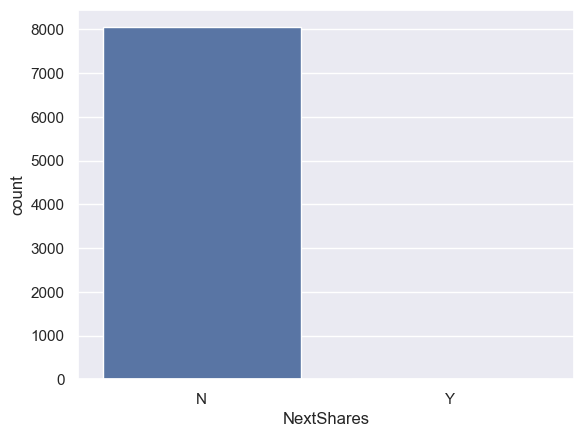

In [69]:
sns.countplot(x='NextShares',data=df)

In [70]:
df['NextShares'].value_counts(normalize=True)*100

NextShares
N    99.962728
Y     0.037272
Name: proportion, dtype: float64

The **NextShares** distribution shows that almost all securities in the dataset (**~99.96%**) are marked as **“N”**, indicating that they are regular securities and not part of the NextShares structure. Only a very tiny fraction (**~0.04%**) belongs to the **NextShares category**, making it an extremely rare feature within the dataset.

This suggests that NextShares products never became a major part of mainstream trading activity in markets like the Nasdaq Stock Market. Instead, traditional company stocks and ETFs continue to dominate the market ecosystem. The extremely small presence of NextShares also explains why the feature contributes very little variation to the dataset and may have limited analytical importance.

Overall, the distribution highlights how certain experimental or niche financial products exist in the market but remain far less common compared to standard investment instruments such as regular equities and ETFs.


## Univariate Analysis Summary and Insights
The univariate analysis provides a broad understanding of the structure and composition of securities traded across major U.S. exchanges, particularly the Nasdaq Stock Market. The dataset is heavily dominated by mainstream exchange listings, with the largest share of securities belonging to Nasdaq-related categories, followed by listings from the New York Stock Exchange and NYSE Arca. This indicates that the dataset primarily captures actively traded and widely recognized financial instruments within the U.S. market ecosystem.

A major insight from the analysis is the strong presence of financial stability across the dataset. Nearly all securities are classified under the “Normal” financial status category, suggesting that most listed entities comply with required financial and regulatory standards. Only a very small fraction of securities fall into deficient or delinquent categories, indicating that financially distressed or non-compliant firms represent a minor segment of the market. This reflects the relatively strict listing and compliance requirements maintained by major exchanges. At the same time, these smaller high-risk groups remain important from a market surveillance and risk-analysis perspective, as they may carry higher uncertainty and potential delisting risk.

The analysis also highlights the growing role of ETFs (Exchange-Traded Funds) in modern financial markets. While traditional non-ETF securities still form the majority of the dataset, ETFs account for a substantial portion of all listings, demonstrating how investment activity has expanded beyond individual company stocks toward diversified and index-based investment products. The Market Category distribution further supports this observation, as a large percentage of entries either belong to ETFs or fall outside the standard Nasdaq company-tier classification system. This suggests that the modern market environment includes a wide variety of financial instruments rather than only traditional corporate equities.

Another important finding is the high degree of standardization present in the dataset. Features such as Round Lot Size show almost no variation, with nearly all securities traded in the standard lot size of 100 shares. Similarly, columns like Nasdaq Traded and Test Issue contain only a single dominant value, confirming that the dataset consists almost entirely of real, actively traded Nasdaq securities. Identifier-based columns such as Symbol, NASDAQ Symbol, and CQS Symbol are largely unique for each security and primarily serve reference purposes rather than contributing meaningful analytical patterns. The strong overlap between NASDAQ Symbol and CQS Symbol also indicates a highly standardized system for identifying securities across U.S. trading platforms.

Overall, the univariate analysis reveals a market ecosystem dominated by financially stable, actively traded securities listed on major U.S. exchanges, while also highlighting the significant presence of ETFs and other non-traditional investment instruments. The dataset reflects the diversity, structure, and operational standardization of modern financial markets, while the cleaning and preprocessing steps helped distinguish truly informative features from redundant or low-variation columns.


## Bivariate Analysis

### Listing Exchange vs ETF

In [71]:
pd.crosstab(df['Listing Exchange'], df['ETF'])

ETF,N,Y
Listing Exchange,,
A,252,1
N,2520,0
P,107,1435
Q,2988,395
Z,17,334


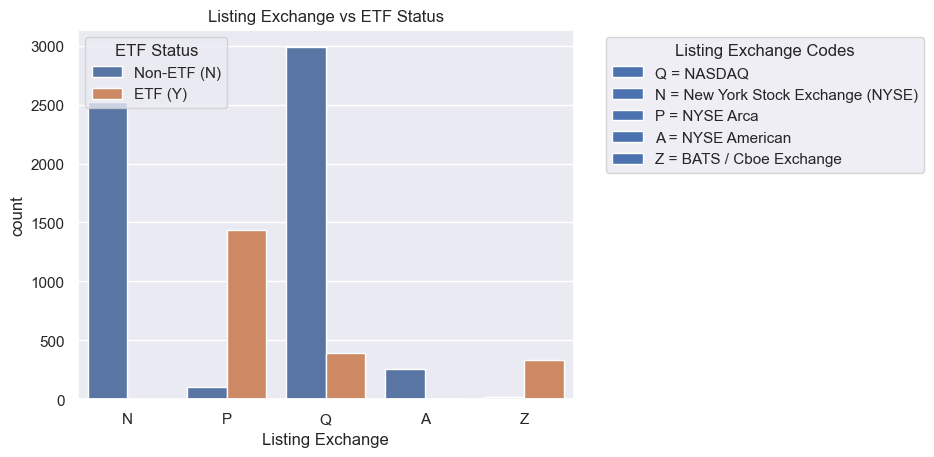

In [72]:

# Create plot
ax = sns.countplot(x='Listing Exchange', data=df, hue='ETF')

# First legend (ETF)
legend1 = ax.legend(title='ETF Status',
                    labels=['Non-ETF (N)', 'ETF (Y)'],
                    loc='upper left')

# Add first legend manually
ax.add_artist(legend1)

# Second legend (Listing Exchange full forms)
exchange_labels = {
    'Q': 'NASDAQ',
    'N': 'New York Stock Exchange (NYSE)',
    'P': 'NYSE Arca',
    'A': 'NYSE American',
    'Z': 'BATS / Cboe Exchange'
}

patches = [
    mpatches.Patch(label=f"{k} = {v}")
    for k, v in exchange_labels.items()
]

# Second legend
ax.legend(handles=patches,
          title='Listing Exchange Codes',
          bbox_to_anchor=(1.05, 1),
          loc='upper left')

plt.title('Listing Exchange vs ETF Status')
plt.show()

The relationship between **ETF status** and **Listing Exchange** reveals a very clear structural pattern in how different exchanges specialize within the U.S. financial market ecosystem. Securities listed under the **N category (NYSE)** are entirely non-ETF securities, suggesting that this exchange segment is dominated by traditional company stocks and corporate listings. Similarly, the **A category (NYSE American)** also contains almost exclusively non-ETF securities, reinforcing its focus on regular equity listings rather than investment funds.

In contrast, the **P category (NYSE Arca)** is heavily dominated by ETFs, with ETF listings vastly outnumbering non-ETF securities. This strongly aligns with the real-world role of NYSE Arca as one of the major exchanges for ETF trading in the United States. The **Z category** also shows a strong ETF concentration, indicating that certain alternative exchanges are more actively used for fund-based and exchange-traded investment products.

The **Q category (Nasdaq)** presents a more balanced structure. While traditional non-ETF securities still form the majority, Nasdaq also hosts a notable number of ETFs, reflecting its broad and diversified market presence. This suggests that Nasdaq serves both as a major hub for corporate equities—especially technology and growth-oriented firms—and as an important platform for modern investment instruments.

Overall, the analysis demonstrates that different exchanges are not used uniformly across all security types. Instead, each exchange appears to have a distinct market role, with some specializing in traditional company listings while others are more heavily associated with ETFs and exchange-traded investment products.


### **Listing Exchange vs Financial Status**

In [73]:
pd.crosstab(df['Listing Exchange'], df['Financial Status'])

Financial Status,D,E,H,N
Listing Exchange,,,,
A,0,0,0,253
N,0,0,0,2520
P,0,0,0,1542
Q,191,8,4,3180
Z,0,0,0,351


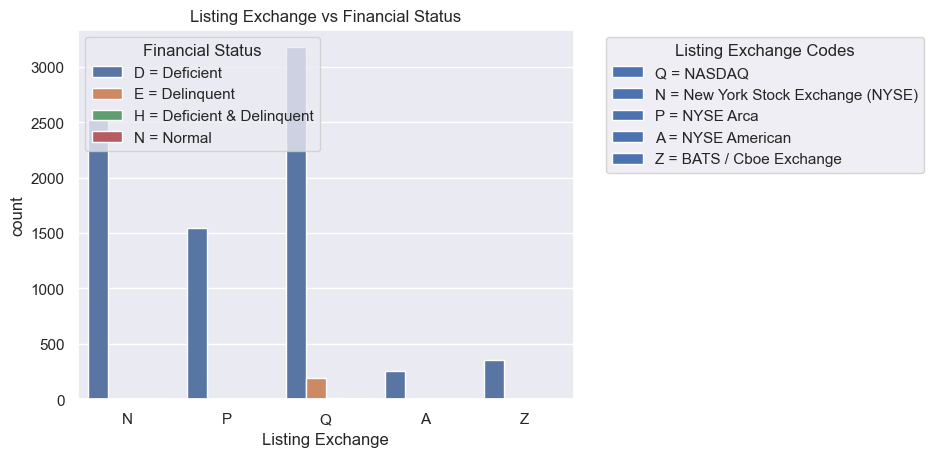

In [74]:
# Create plot
ax = sns.countplot(x='Listing Exchange',
                   data=df,
                   hue='Financial Status')

# First legend: Financial Status
legend1 = ax.legend(
    title='Financial Status',
    labels=[
        'D = Deficient',
        'E = Delinquent',
        'H = Deficient & Delinquent',
        'N = Normal'
    ],
    loc='upper left'
)

# Keep first legend
ax.add_artist(legend1)

# Second legend: Listing Exchange full forms
exchange_labels = {
    'Q': 'NASDAQ',
    'N': 'New York Stock Exchange (NYSE)',
    'P': 'NYSE Arca',
    'A': 'NYSE American',
    'Z': 'BATS / Cboe Exchange'
}

patches = [
    mpatches.Patch(label=f"{k} = {v}")
    for k, v in exchange_labels.items()
]

# Second legend
ax.legend(handles=patches,
          title='Listing Exchange Codes',
          bbox_to_anchor=(1.05, 1),
          loc='upper left')

plt.title('Listing Exchange vs Financial Status')
plt.show()

The relationship between **Listing Exchange** and **Financial Status** reveals that financial compliance issues in the dataset are highly concentrated within the **Q exchange category (Nasdaq)**. While the vast majority of securities across all exchanges are classified as **Normal (N)**, the only occurrences of **Deficient (D)**, **Delinquent (E)**, and **Deficient & Delinquent (H)** statuses appear within Nasdaq-listed securities.

Exchanges represented by the **A, N, P, and Z categories** show complete financial stability in this dataset, with all listed securities falling under the Normal category. This suggests that securities traded on these exchanges either maintain strong compliance standards or that the dataset contains primarily financially healthy entities from these segments.

The **Q category**, however, contains a small but noticeable number of financially problematic securities, including companies with reporting deficiencies or delayed regulatory filings. Although these risky securities still represent a very small fraction compared to the large number of normal Nasdaq listings, the presence of all risk-related statuses within this category may indicate that Nasdaq hosts a broader and more diverse range of companies, including newer, growth-oriented, or relatively volatile firms.

Overall, the analysis suggests that while the U.S. market ecosystem is overwhelmingly dominated by financially stable securities, financial risk and compliance-related irregularities are primarily concentrated within the Nasdaq segment of the dataset.


### **Market Category vs ETF**

In [75]:
pd.crosstab(df['Market Category'], df['ETF'])

ETF,N,Y
Market Category,,
ETF,0,2165
G,505,0
Not Applicable,2896,0
Q,1531,0
S,952,0


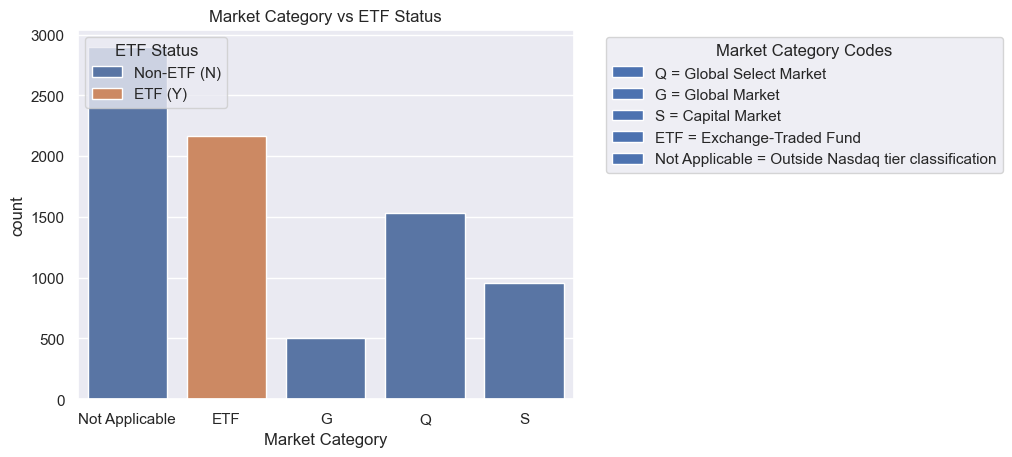

In [76]:
# Create countplot
ax = sns.countplot(x='Market Category',
                   data=df,
                   hue='ETF')

# First legend: ETF status
legend1 = ax.legend(
    title='ETF Status',
    labels=[
        'Non-ETF (N)',
        'ETF (Y)'
    ],
    loc='upper left'
)

# Keep first legend
ax.add_artist(legend1)

# Second legend: Market Category full forms
market_labels = {
    'Q': 'Global Select Market',
    'G': 'Global Market',
    'S': 'Capital Market',
    'ETF': 'Exchange-Traded Fund',
    'Not Applicable': 'Outside Nasdaq tier classification'
}

patches = [
    mpatches.Patch(label=f"{k} = {v}")
    for k, v in market_labels.items()
]

# Second legend
ax.legend(handles=patches,
          title='Market Category Codes',
          bbox_to_anchor=(1.05, 1),
          loc='upper left')

plt.title('Market Category vs ETF Status')
plt.show()

The relationship between **ETF status** and **Market Category** reveals a very strong structural separation between ETFs and traditional company listings. All securities classified under the **ETF market category** are marked as ETFs (`Y`), while all securities belonging to the **Q, G, S, and Not Applicable** categories are non-ETF securities (`N`). This confirms that ETFs operate as a distinct segment within the dataset rather than being mixed with standard company-tier classifications.

The analysis also validates the preprocessing approach used during cleaning. Blank market category values associated with ETF securities were correctly relabeled as **“ETF”**, since these securities do not belong to Nasdaq’s traditional company classification system. Similarly, the **Q, G, and S** categories remain exclusive to regular corporate listings, representing companies of different sizes and listing standards.

Another important insight is the large number of securities under the **Not Applicable** category, all of which are non-ETF securities. This suggests the presence of other specialized or non-traditional financial instruments that fall outside the standard Nasdaq market-tier framework but are still not classified as ETFs.

Overall, the analysis highlights that the dataset contains clearly separated market structures: traditional company equities categorized by market tier, ETFs operating as investment products, and additional specialized securities grouped under non-applicable classifications.


### Listing Exchange vs Test Issue

In [77]:
pd.crosstab(df['Listing Exchange'], df['Test Issue'])


Test Issue,N
Listing Exchange,
A,253
N,2520
P,1542
Q,3383
Z,351


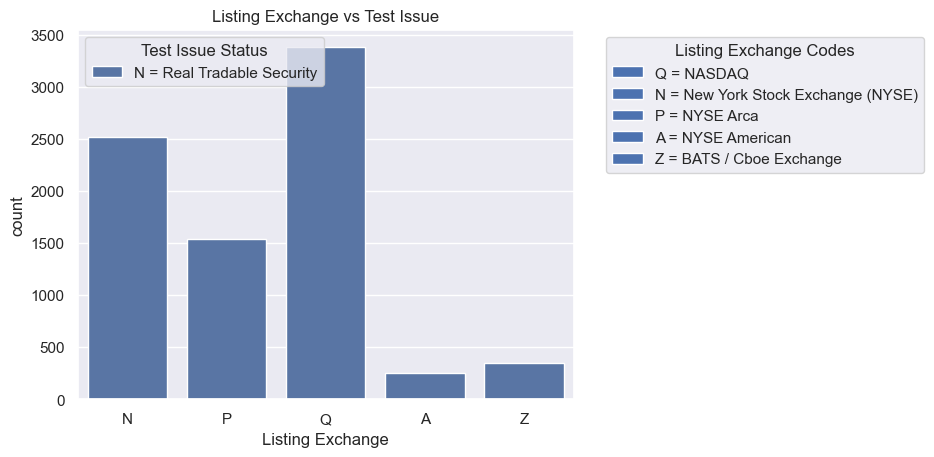

In [78]:


ax = sns.countplot(x='Listing Exchange',
                   data=df,
                   hue='Test Issue')

# First legend: Test Issue
legend1 = ax.legend(
    title='Test Issue Status',
    labels=['N = Real Tradable Security'],
    loc='upper left'
)

# Keep first legend
ax.add_artist(legend1)

# Second legend: Listing Exchange full forms
exchange_labels = {
    'Q': 'NASDAQ',
    'N': 'New York Stock Exchange (NYSE)',
    'P': 'NYSE Arca',
    'A': 'NYSE American',
    'Z': 'BATS / Cboe Exchange'
}

patches = [
    mpatches.Patch(label=f"{k} = {v}")
    for k, v in exchange_labels.items()
]

# Second legend
ax.legend(handles=patches,
          title='Listing Exchange Codes',
          bbox_to_anchor=(1.05, 1),
          loc='upper left')

plt.title('Listing Exchange vs Test Issue')
plt.show()

The relationship between Test Issue and Listing Exchange shows that all securities across every exchange category are marked as “N” (Not a Test Issue). This means the dataset contains only real, actively traded securities and does not include any dummy or system-testing entries. Whether the security belongs to Nasdaq, NYSE, NYSE Arca, or other exchange categories, every listing represents an actual market-traded financial instrument.
The absence of any “Y” values also indicates that the Test Issue column has no variation across the dataset. From an analytical perspective, this makes the feature non-informative, since it does not help distinguish between different types of securities or reveal any meaningful market patterns. However, it still provides an important data-quality confirmation by verifying that the dataset consists entirely of legitimate exchange-listed securities.
Overall, the analysis reinforces the reliability and authenticity of the dataset while also highlighting why the Test Issue column can be safely removed during preprocessing due to its constant nature.

In [79]:
pd.crosstab(df['ETF'], df['NextShares'])

NextShares,N,Y
ETF,,
N,5881,3
Y,2165,0


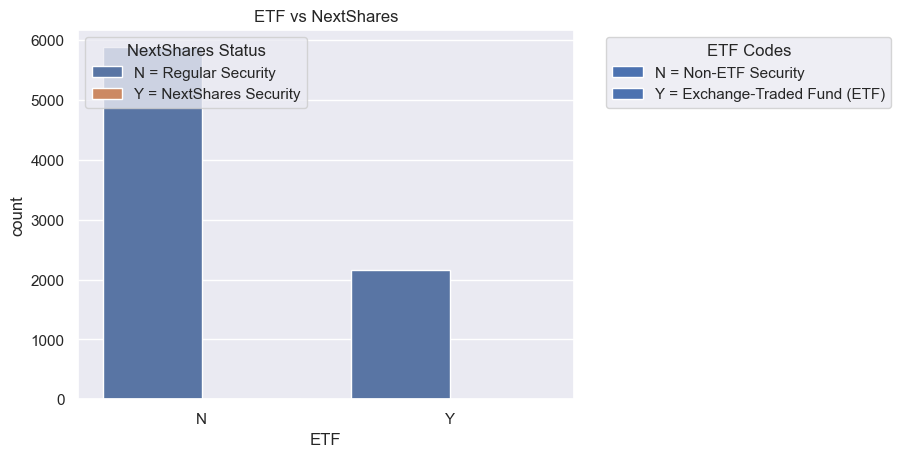

In [80]:

ax = sns.countplot(x='ETF',
                   data=df,
                   hue='NextShares')

# First legend: NextShares
legend1 = ax.legend(
    title='NextShares Status',
    labels=[
        'N = Regular Security',
        'Y = NextShares Security'
    ],
    loc='upper left'
)

# Keep first legend
ax.add_artist(legend1)

# Second legend: ETF full forms
etf_labels = {
    'N': 'Non-ETF Security',
    'Y': 'Exchange-Traded Fund (ETF)'
}

patches = [
    mpatches.Patch(label=f"{k} = {v}")
    for k, v in etf_labels.items()
]

# Second legend
ax.legend(handles=patches,
          title='ETF Codes',
          bbox_to_anchor=(1.05, 1),
          loc='upper left')

plt.title('ETF vs NextShares')
plt.show()

The relationship between NextShares and ETF status shows that NextShares securities are extremely rare within the dataset. Almost all non-ETF securities are classified as regular securities (N), with only 3 entries marked as NextShares (Y). At the same time, none of the ETF securities belong to the NextShares category.

This suggests that NextShares operate as a highly specialized and niche financial product rather than a mainstream investment instrument like ETFs. While ETFs form a significant portion of the dataset and are widely used in modern financial markets, NextShares have almost no presence, indicating very limited adoption in real-world trading activity.

Another important insight is that NextShares appear only among non-ETF securities, further reinforcing that they represent a structurally different type of investment product. Overall, the analysis highlights the dominance of traditional securities and ETFs in the market, while experimental or alternative financial products such as NextShares remain extremely uncommon.

## Multivariate Analysis

#### Heatmap of Correlation

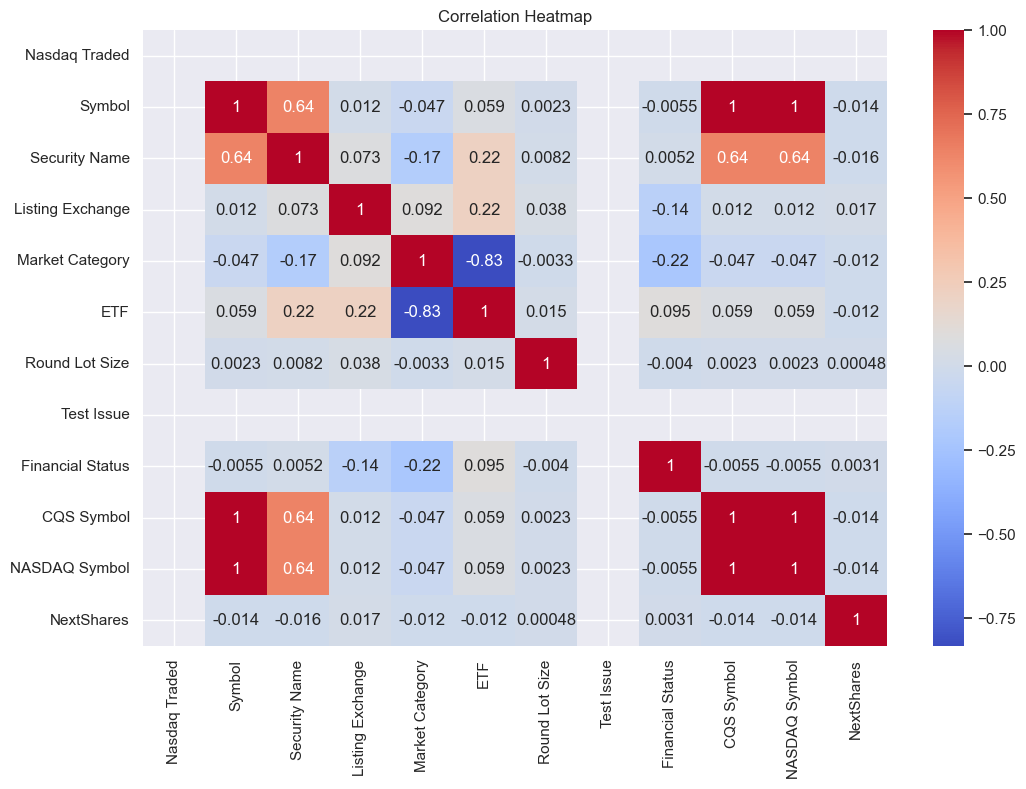

In [82]:
# Encoding categorical columns
encoded_df = df.copy()

for col in encoded_df.select_dtypes(include='object').columns:
    encoded_df[col] = encoded_df[col].astype('category').cat.codes

# Correlation matrix
corr = encoded_df.corr()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Heatmap shows relationships between variables.
Darker colors indicate stronger relationships.
Deep Insight

Most variables have weak correlation because this is metadata, not stock price data.

### GroupBy Analysis 1

In [83]:
exchange_group = df.groupby('Listing Exchange')['Round Lot Size'].mean().sort_values(ascending=False)
print(exchange_group)

Listing Exchange
P    100.000000
Q    100.000000
Z    100.000000
N     99.892857
A     99.252964
Name: Round Lot Size, dtype: float64


Some exchanges support larger average trade sizes

### GroupBy Analysis 2

In [84]:
etf_exchange = df.groupby('Listing Exchange')['ETF'].value_counts()
print(etf_exchange)

Listing Exchange  ETF
A                 N       252
                  Y         1
N                 N      2520
P                 Y      1435
                  N       107
Q                 N      2988
                  Y       395
Z                 Y       334
                  N        17
Name: count, dtype: int64


Certain exchanges focus more heavily on ETFs.

### GroupBy Analysis 3

In [85]:
financial_market = df.groupby('Market Category')['Financial Status'].value_counts()
print(financial_market)

Market Category  Financial Status
ETF              N                   2164
                 D                      1
G                N                    488
                 D                     15
                 E                      2
Not Applicable   N                   2896
Q                N                   1517
                 D                     11
                 E                      3
S                N                    781
                 D                    164
                 H                      4
                 E                      3
Name: count, dtype: int64


Some market categories contain more financially stable securities.

### Advanced Data Scientist Insights

The stock market heavily relies on standardized lot sizes.
ETF listings are concentrated on specific exchanges.
Ticker symbols are highly standardized with very low inconsistency.
Metadata datasets generally show low correlation because variables represent categories rather than continuous numerical behavior.
Missing Financial Status values likely represent unavailable classifications rather than errors.

### Final Conclusions

Key Findings Most securities are Nasdaq traded. Round Lot Size = 100 is industry standard. Non-ETF securities dominate the market. Exchanges differ significantly in security distribution. Symbol inconsistencies are extremely rare. Financial Status contains many missing/unknown values.